In [ ]:
import pandas as pd 
import numpy as np 

In [2]:
df = pd.read_excel("../data/raw/Online Retail.xlsx")

In [3]:
df = df.dropna(subset=["CustomerID"])
df = df[df["Quantity"] > 0]
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

In [4]:
import datetime as dt

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
reference_date = df["InvoiceDate"].max() + dt.timedelta(days=1)

In [5]:
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (reference_date - x.max()).days,
    "InvoiceNo": "count",
    "Revenue": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,182,4310.00
12348.0,75,31,1797.24
12349.0,19,73,1757.55
12350.0,310,17,334.40


In [6]:
threshold = rfm["Recency"].quantile(0.75)
threshold

np.float64(142.0)

In [7]:
rfm["Churn"] = rfm["Recency"].apply(lambda x: 1 if x > threshold else 0)

In [8]:
rfm["Churn"].value_counts()

Churn
0    3255
1    1084
Name: count, dtype: int64

In [9]:
from sklearn.model_selection import train_test_split

x = rfm[["Frequency", "Monetary"]]
y = rfm["Churn"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [10]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight="balanced")
model.fit(x_train,y_train)

LogisticRegression(class_weight='balanced')

In [11]:
y_pred = model.predict(x_test)

In [12]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.6440092165898618

In [13]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
cm

array([[384, 266],
       [ 43, 175]])

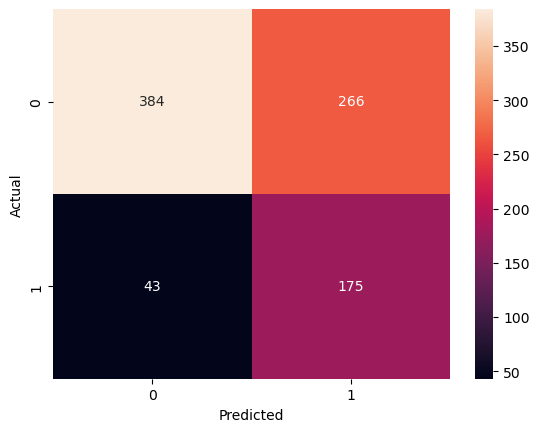

In [14]:
import seaborn as sns 
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [15]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.59      0.71       650
           1       0.40      0.80      0.53       218

    accuracy                           0.64       868
   macro avg       0.65      0.70      0.62       868
weighted avg       0.77      0.64      0.67       868



In [16]:
model.coef_

array([[-1.87454997e-02, -2.87555854e-05]])

In [17]:
pd.DataFrame({
    "Feature": x.columns,
    "Coefficient": model.coef_[0]
})

,Feature,Coefficient
0,Frequency,-0.018745
1,Monetary,-0.000029


In [18]:
from sklearn.ensemble import RandomForestClassifier

In [26]:
rf_model = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"
    )

In [27]:
rf_model.fit(x_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [28]:
y_pred_rf = rf_model.predict(x_test)

In [29]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.81      0.89      0.85       650
           1       0.53      0.36      0.43       218

    accuracy                           0.76       868
   macro avg       0.67      0.63      0.64       868
weighted avg       0.74      0.76      0.74       868



In [30]:
pd.DataFrame({
    "Feature": x.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

,Feature,Importance
1,Monetary,0.682464
0,Frequency,0.317536


In [31]:
y_prob = model.predict_proba(x_test)[:,1]

In [32]:
y_pred_custom = (y_prob > 0.3).astype(int)

In [33]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       0.95      0.37      0.53       650
           1       0.33      0.94      0.49       218

    accuracy                           0.51       868
   macro avg       0.64      0.65      0.51       868
weighted avg       0.79      0.51      0.52       868



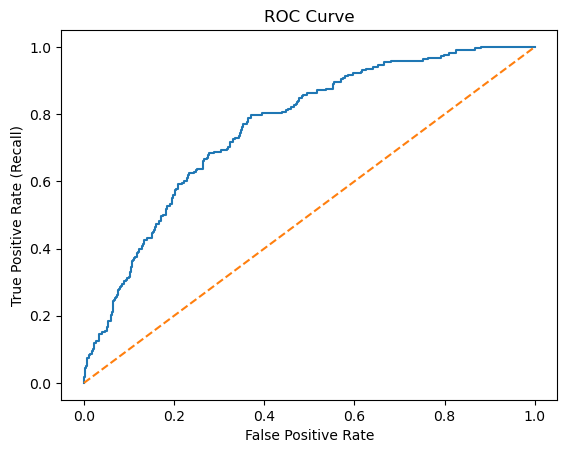

In [41]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# probability
y_prob = model.predict_proba(x_test)[:,1]

# ROC

fpr, tpr, threshold = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.show()

In [35]:
roc_auc_score(y_test, y_prob)

np.float64(0.7618419195483417)

In [39]:
import numpy as np 
from sklearn.metrics import f1_score

thresholds = np.arange(0.1, 0.9, 0.05)

best_threshold = 0
best_f1 = 0

for t in threshold:
    y_pred_temp = (y_prob > t).astype(int)
    f1 = f1_score(y_test, y_pred_temp)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t


best_threshold, best_f1

(np.float64(0.515102585812275), 0.5474683544303798)

In [40]:
y_pred_best = (y_prob > best_threshold).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.90      0.63      0.74       650
           1       0.42      0.79      0.55       218

    accuracy                           0.67       868
   macro avg       0.66      0.71      0.64       868
weighted avg       0.78      0.67      0.69       868

